In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.metrics import RocCurveDisplay

In [2]:
df=pd.read_csv("E:\MachineLearning\Data\weatherAUS2.csv")  

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\E C\AppData\Local\Temp\ipykernel_16116\4216795759.py:1: SyntaxWarning: invalid escape sequence '\M'
  df=pd.read_csv("E:\MachineLearning\Data\weatherAUS2.csv")


In [3]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  str    
 1   Location       142193 non-null  str    
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  str    
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  str    
 10  WindDir3pm     138415 non-null  str    
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null   float64


In [5]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


In [6]:
df.isnull().sum().sort_values(ascending=False)

Sunshine         67816
Evaporation      60843
Cloud3pm         57094
Cloud9am         53657
Pressure9am      14014
Pressure3pm      13981
WindDir9am       10013
WindGustDir       9330
WindGustSpeed     9270
WindDir3pm        3778
Humidity3pm       3610
Temp3pm           2726
WindSpeed3pm      2630
Humidity9am       1774
Rainfall          1406
RainToday         1406
WindSpeed9am      1348
Temp9am            904
MinTemp            637
MaxTemp            322
Location             0
Date                 0
RISK_MM              0
RainTomorrow         0
dtype: int64

In [7]:
missing=pd.DataFrame({
        'Missing Count': df.isnull().sum(),
        'missing per':df.isnull().mean() * 100,
        'dtype':df.dtypes
}).sort_values('missing per', ascending=False)
missing

,Missing Count,missing per,dtype
Sunshine,67816,47.692924,float64
Evaporation,60843,42.789026,float64
Cloud3pm,57094,40.152469,float64
Cloud9am,53657,37.735332,float64
Pressure9am,14014,9.855619,float64
Pressure3pm,13981,9.832411,float64
WindDir9am,10013,7.041838,str
WindGustDir,9330,6.561504,str
WindGustSpeed,9270,6.519308,float64
WindDir3pm,3778,2.656952,str


In [8]:
df['Date']=pd.to_datetime(df['Date'])
df['year']=df['Date'].dt.year
df['month']=df['Date'].dt.month
df['day']=df['Date'].dt.day

In [9]:
df_clean = df.copy()

In [10]:
numeric_cols=df_clean.select_dtypes(include='number').columns
numeric_cols

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RISK_MM', 'year', 'month', 'day'],
      dtype='str')

In [11]:
numeric_cols_tofill=[
     'MinTemp',
    'MaxTemp',
    'Rainfall',
    'WindGustSpeed',
    'WindSpeed9am',
    'WindSpeed3pm',
    'Humidity9am',
    'Humidity3pm',
    'Pressure9am',
    'Pressure3pm',
    'Temp9am',
    'Temp3pm'
]
for col in numeric_cols_tofill:
    df_clean[col]=df_clean[col].fillna(df_clean[col].median())

In [12]:
categorical_cols=[
    'WindGustDir',
    'WindDir9am',
    'WindDir3pm'
]
for col in categorical_cols:
    df_clean[col]=df_clean[col].fillna('Unknown')

In [13]:
df_clean['RainToday']=df_clean['RainToday'].fillna(
    df_clean['RainToday'].mode()[0]
)

In [14]:
df_clean.isnull().sum().sort_values(ascending=False)

Sunshine         67816
Evaporation      60843
Cloud3pm         57094
Cloud9am         53657
Location             0
MinTemp              0
MaxTemp              0
WindGustDir          0
WindGustSpeed        0
Rainfall             0
Date                 0
WindDir3pm           0
WindDir9am           0
WindSpeed9am         0
WindSpeed3pm         0
Humidity3pm          0
Humidity9am          0
Pressure3pm          0
Pressure9am          0
Temp9am              0
Temp3pm              0
RainToday            0
RISK_MM              0
RainTomorrow         0
year                 0
month                0
day                  0
dtype: int64

In [15]:
df_clean.duplicated().sum()

np.int64(0)

In [16]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,142193,2013-04-01 00:28:51.730816,2007-11-01 00:00:00,2011-01-06 00:00:00,2013-05-27 00:00:00,2015-06-12 00:00:00,2017-06-25 00:00:00,NaN
MinTemp,142193.0,12.185565,-8.5,7.6,12.0,16.8,33.9,6.388936
MaxTemp,142193.0,23.225365,-4.8,17.9,22.6,28.2,48.1,7.109617
Rainfall,142193.0,2.326738,0.0,0.0,0.0,0.6,371.0,8.426426
Evaporation,81350.0,5.469824,0.0,2.6,4.8,7.4,145.0,4.188537
Sunshine,74377.0,7.624853,0.0,4.9,8.5,10.6,14.5,3.781525
WindGustSpeed,142193.0,39.920123,6.0,31.0,39.0,46.0,135.0,13.140632
WindSpeed9am,142193.0,13.992489,0.0,7.0,13.0,19.0,130.0,8.851614
WindSpeed3pm,142193.0,18.644279,0.0,13.0,19.0,24.0,87.0,8.721688
Humidity9am,142193.0,68.858235,0.0,57.0,70.0,83.0,100.0,18.932512


Text(0.5, 1.0, 'Rain Tomorrow Count')

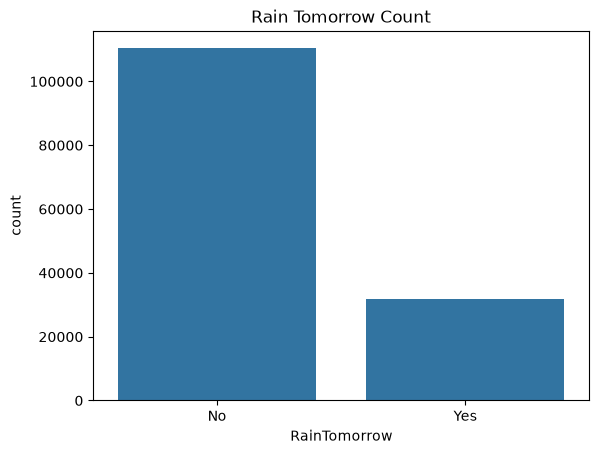

In [17]:
sns.countplot(data=df_clean,x='RainTomorrow')
plt.title('Rain Tomorrow Count')
#Both target variables show a significant class imbalance; non-rainy days (No) heavily dominate the dataset compared to rainy days Yes

Text(0.5, 1.0, 'Rain Today Count')

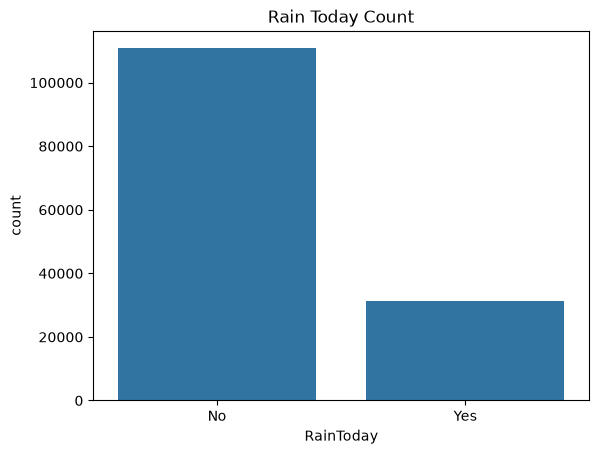

In [18]:
sns.countplot(data=df_clean,x='RainToday')
plt.title('Rain Today Count')
#The distribution of RainToday matches RainTomorrow almost identically, highlighting a consistent weather pattern in the recorded locations

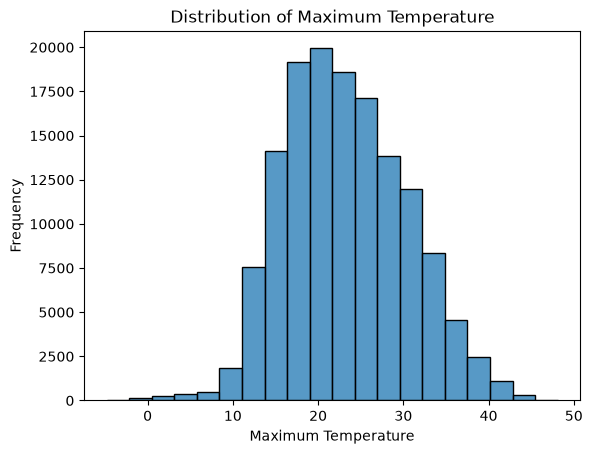

In [19]:
sns.histplot(data=df_clean,x='MaxTemp',bins=20)
plt.title('Distribution of Maximum Temperature')
plt.xlabel('Maximum Temperature')
plt.ylabel('Frequency')
plt.show()
#  normal distribution centered around 20:22, with the highest frequency  20,000 counts

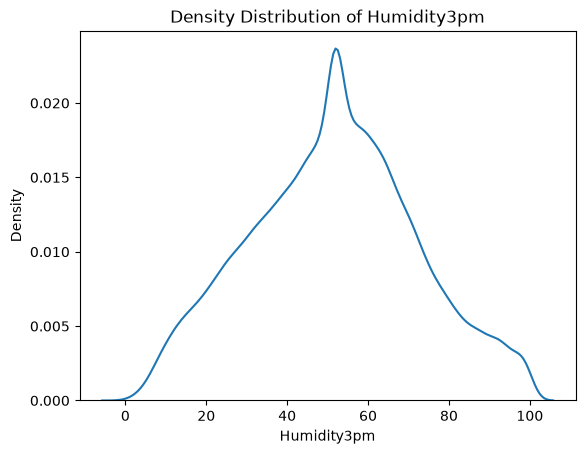

In [20]:
sns.kdeplot(df_clean,x='Humidity3pm')
plt.title('Density Distribution of Humidity3pm')
plt.show()
# Humidity3pm shows a distinct peak density around 50, indicating that moderate afternoon humidity is the most common state

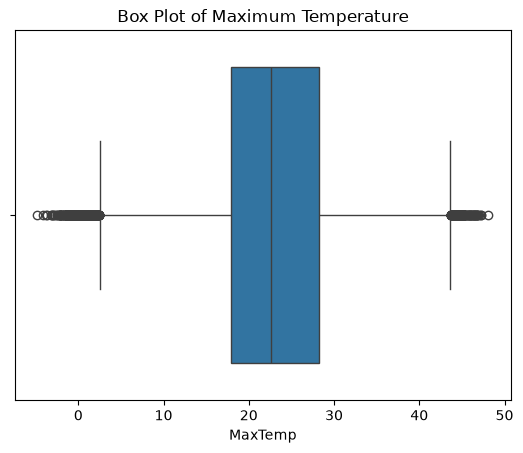

In [21]:
sns.boxplot(data=df_clean,x='MaxTemp')
plt.title('Box Plot of Maximum Temperature')
plt.show()
#The Box Plot highlights minor outliers on both ends: extremely cold days (<3) and extremely hot days >44

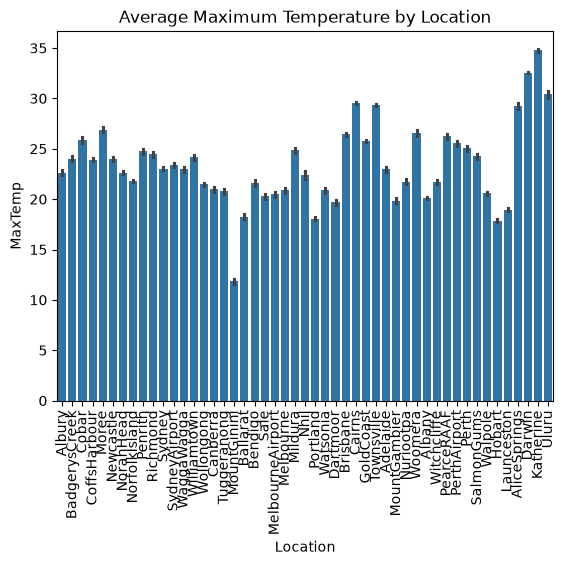

In [22]:
sns.barplot(data=df_clean,x='Location',y='MaxTemp')
plt.title('Average Maximum Temperature by Location')
plt.xticks(rotation=90)
plt.show()


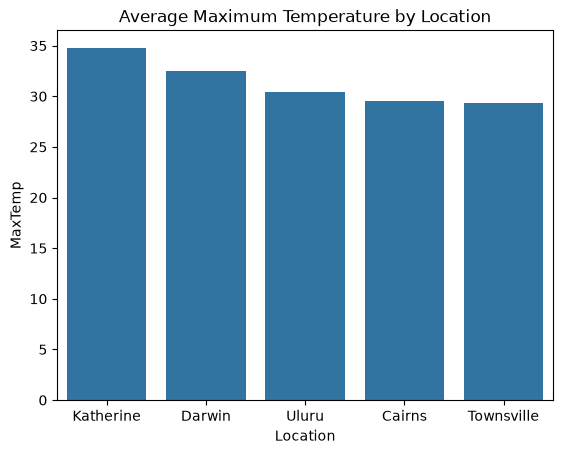

In [23]:
top5=df_clean.groupby('Location')['MaxTemp'].mean().nlargest(5).reset_index()
sns.barplot(data=top5,x='Location',y='MaxTemp')
plt.title('Average Maximum Temperature by Location')
plt.show()
# Katherine and Darwin record the highest average maximum temperatures
#The top 5 hot locations are Katherine, Darwin, Uluru, Cairns, and Townsvill

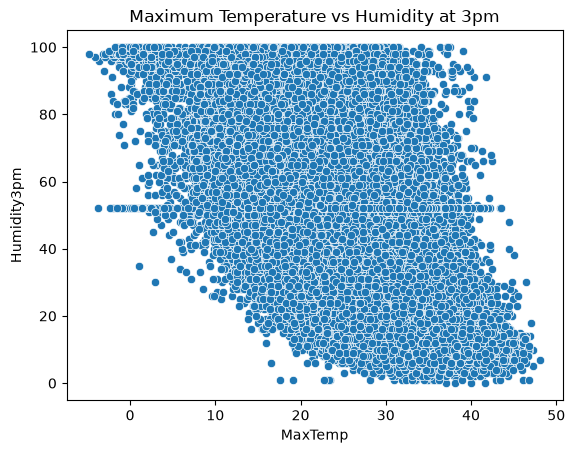

In [24]:
sns.scatterplot(data=df_clean,x='MaxTemp',y='Humidity3pm')
plt.title('Maximum Temperature vs Humidity at 3pm')
plt.show()
# negative correlation between MaxTemp and Humidity3pm as the maximum temperature increases, relative humidity at 3pm drops

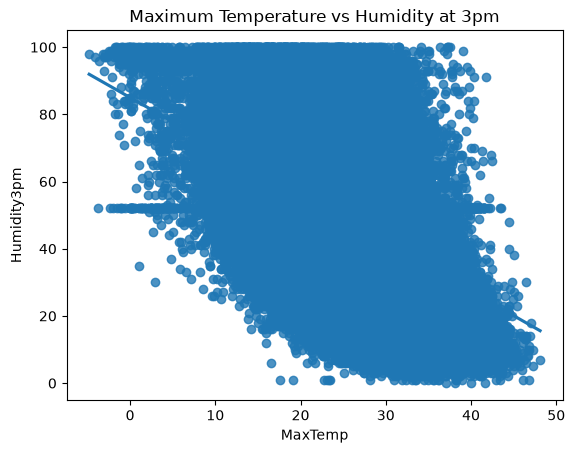

In [25]:
sns.regplot(data=df_clean,x='MaxTemp',y='Humidity3pm')
plt.title('Maximum Temperature vs Humidity at 3pm')
plt.show()
#The regression line in regplot confirms a consistent downward slope

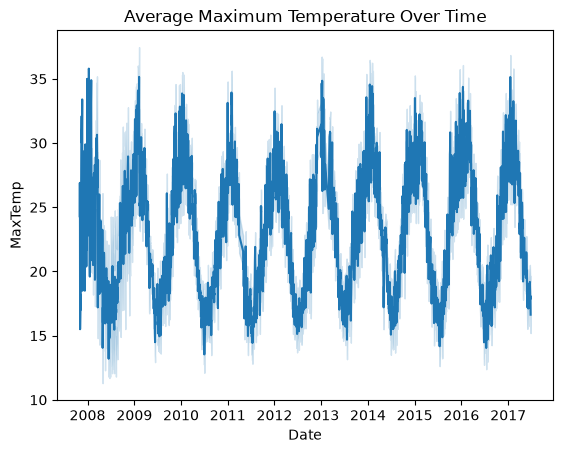

In [26]:
sns.lineplot(data=df_clean,x='Date',y='MaxTemp')
plt.title('Average Maximum Temperature Over Time')
plt.show()
#Clear seasonal periodicity over the years : temperatures peak during summer months and drop consistently in winter 
#Stable overall trend with no drastic upward or downward shifts in average maximum temperatures between 2008 and 2017

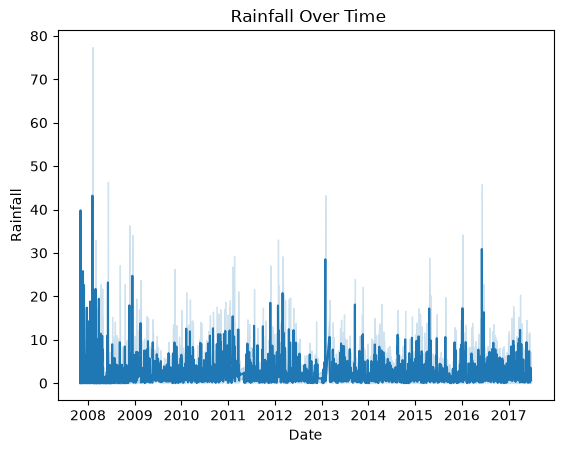

In [27]:
sns.lineplot(data=df_clean,x='Date',y='Rainfall')
plt.title(' Rainfall Over Time')
plt.show()
#Rainfall stays mostly low 10, but displays sudden high extreme spikes, with a major record peak occurring around 2008 ->80

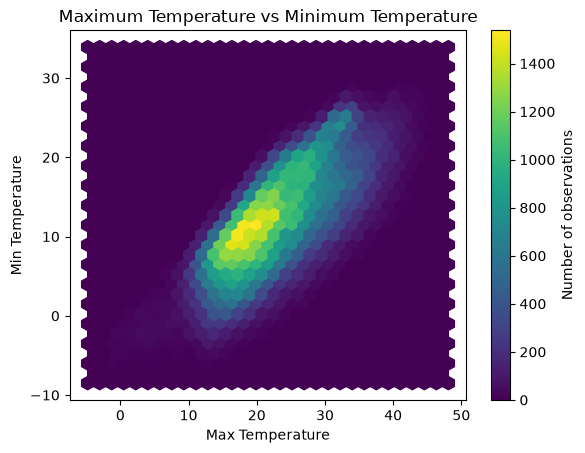

In [28]:
plt.hexbin(
    df_clean['MaxTemp'],
    df_clean['MinTemp'],
    gridsize=30
)

plt.title('Maximum Temperature vs Minimum Temperature')
plt.colorbar(label='Number of observations')
plt.xlabel('Max Temperature')
plt.ylabel('Min Temperature')
plt.show()
#High concentration of observations (yellow/bright zone) occurs around 20 MaxTemp and 10 MinTemp, indicating the most frequent weather condition

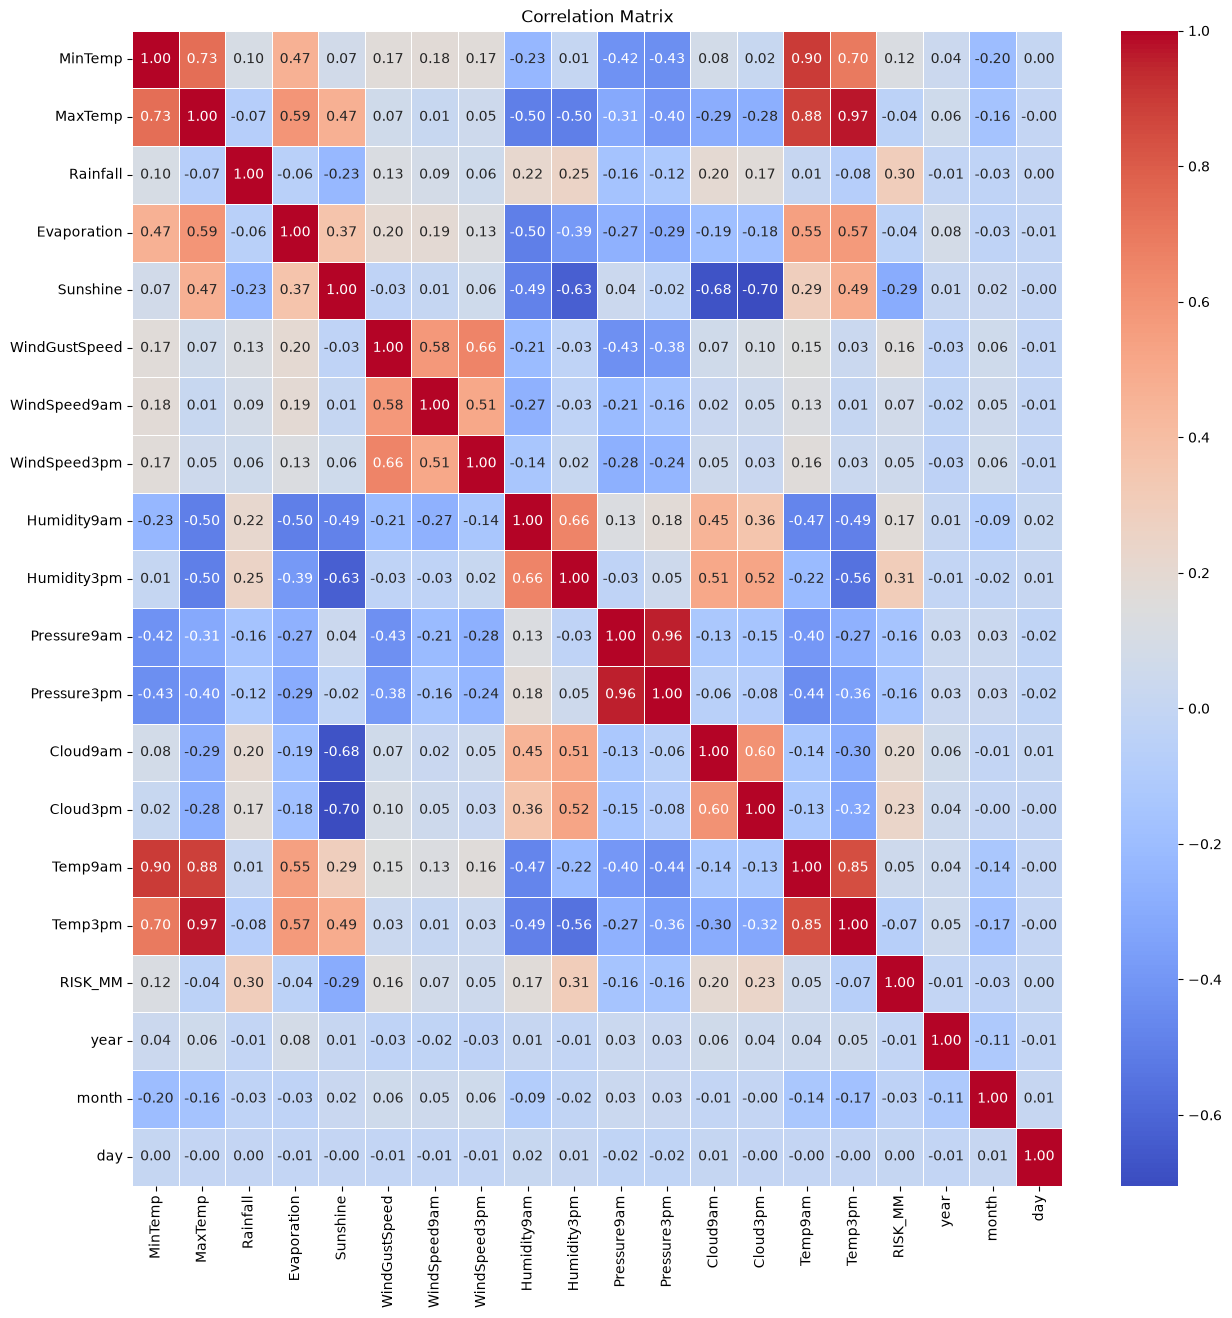

In [29]:
plt.figure(figsize=(15, 15))
corr=df_clean.select_dtypes(include='number').corr()
sns.heatmap(corr,cmap='coolwarm',annot=True, fmt='.2f',  linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

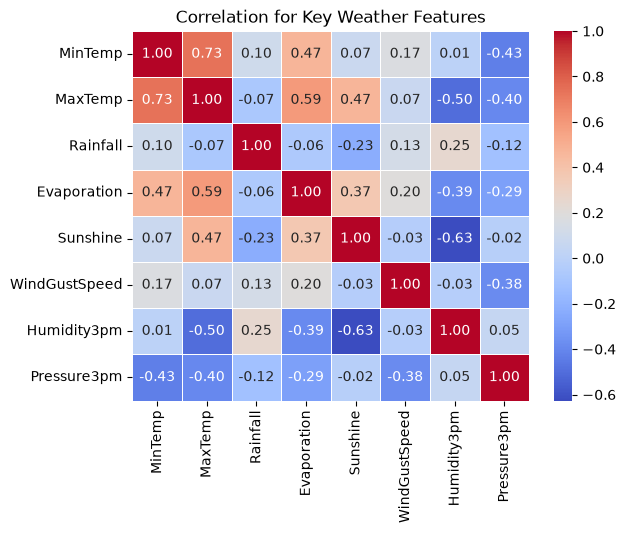

In [30]:
selected_cols = [
    'MinTemp', 
    'MaxTemp', 
    'Rainfall', 
    'Evaporation', 
    'Sunshine', 
    'WindGustSpeed', 
    'Humidity3pm', 
    'Pressure3pm'
]
corr_selected = df_clean[selected_cols].corr()
sns.heatmap(corr_selected, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title('Correlation for Key Weather Features')
plt.show()

In [31]:
#High correlation =0.73  between MinTemp and maxtemp
#Strong inverse relationship = -0.63 between Sunshine and Humidity3pm
#Moderate positive correlation = 0.59 between MaxTemp and Evaporation

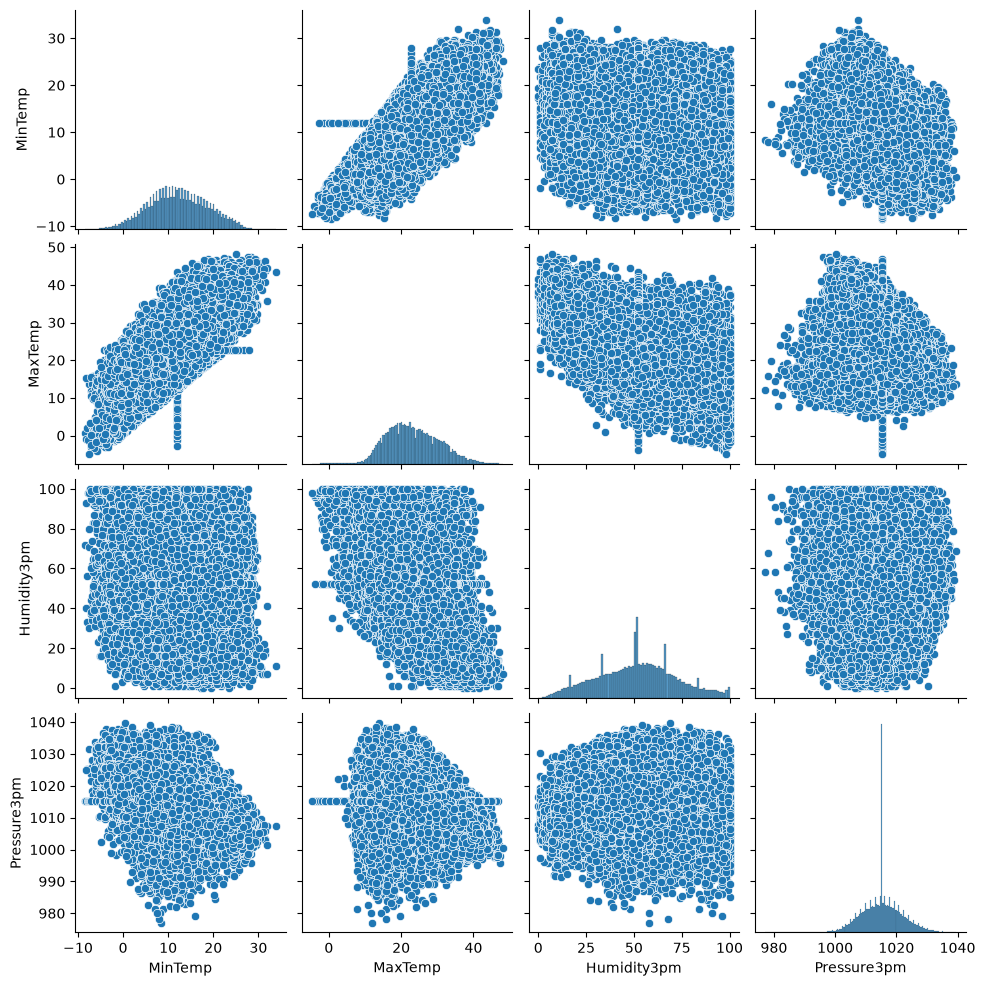

In [32]:
pair_cols = [
    'MinTemp',
    'MaxTemp',
    'Humidity3pm',
    'Pressure3pm'
]
sns.pairplot(data=df_clean[pair_cols].dropna())
plt.show()

In [33]:
#Strong positive correlation between MinTemp and MaxTemp  :minimum temperature rises, maximum temperature incr
# Moderate negative correlation between MaxTemp and Humidity3pm  : higher afternoon temperatures correspond to lower relative humidit
#EN: Pressure3pm and MinTemp display near-normal  distribution


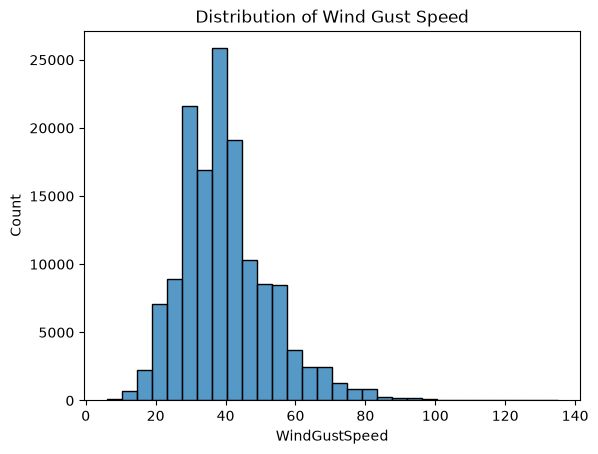

In [34]:
sns.histplot(data=df_clean, x='WindGustSpeed', bins=30)
plt.title('Distribution of Wind Gust Speed')
plt.show()
#WindGustSpeed follows a right- distribution; most gust speeds peak between 30 and 45, with rare severe wind gusts exceeding 80.

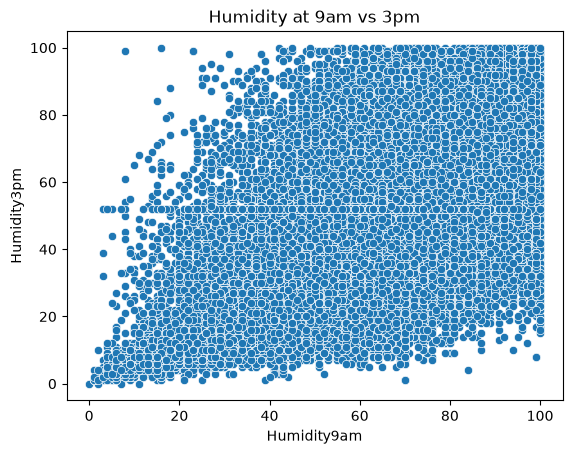

In [35]:
sns.scatterplot(
    data=df_clean,
    x='Humidity9am',
    y='Humidity3pm'
)

plt.title('Humidity at 9am vs 3pm')
plt.show()
#Moderate to strong positive correlation exists between morning 9 am and afternoon 3 pm humidity , higher humidity in the morning generally leads to higher humidity later in the day.

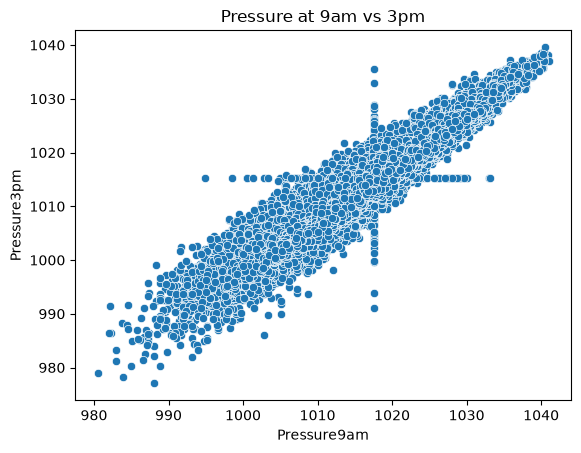

In [36]:
sns.scatterplot(
    data=df_clean,
    x='Pressure9am',
    y='Pressure3pm'
)

plt.title('Pressure at 9am vs 3pm')
plt.show()
#Pressure9am and Pressure3pm show an  strong positive linear relationship , atmospheric pressure remains highly stable throughout the day.

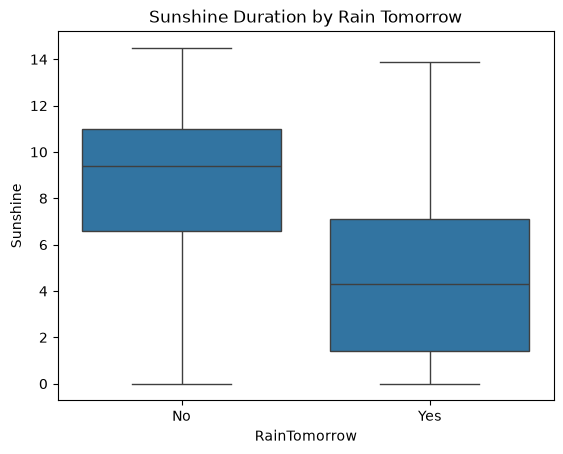

In [37]:
sns.boxplot(
    data=df_clean,
    x='RainTomorrow',
    y='Sunshine'
)

plt.title('Sunshine Duration by Rain Tomorrow')
plt.show()
#Days with higher sunshine duration correspond heavily to dry weather tomorrow (No), with a median of around 9.5 hours. Conversely, rainy days tomorrow (Yes) show significantly lower sunshine median around 4 hours

In [38]:
df_clean=df_clean.drop(columns=['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am', 'RISK_MM'])

In [39]:
categorical_cols=['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']
for col in categorical_cols:
    df_clean[col]=df_clean[col].astype(str).str.strip().str.lower()

In [40]:
df_clean['RainToday_encoded'] = df_clean['RainToday'].map({'yes': 1, 'no': 0})
df_clean['RainTomorrow_encoded'] = df_clean['RainTomorrow'].map({'yes': 1, 'no': 0})

In [41]:
df_clean = df_clean.drop(columns=['RainToday', 'RainTomorrow'])

In [42]:
categorical_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
for col in categorical_cols:
    print(f'{col}: {df_clean[col].unique()}')

Location: <StringArray>
[          'albury',    'badgeryscreek',            'cobar',
     'coffsharbour',            'moree',        'newcastle',
        'norahhead',    'norfolkisland',          'penrith',
         'richmond',           'sydney',    'sydneyairport',
       'waggawagga',      'williamtown',       'wollongong',
         'canberra',      'tuggeranong',      'mountginini',
         'ballarat',          'bendigo',             'sale',
 'melbourneairport',        'melbourne',          'mildura',
             'nhil',         'portland',         'watsonia',
         'dartmoor',         'brisbane',           'cairns',
        'goldcoast',       'townsville',         'adelaide',
     'mountgambier',        'nuriootpa',          'woomera',
           'albany',      'witchcliffe',       'pearceraaf',
     'perthairport',            'perth',       'salmongums',
          'walpole',           'hobart',       'launceston',
     'alicesprings',           'darwin',        'katherine',


In [43]:
print(df_clean.columns.tolist())


['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'year', 'month', 'day', 'RainToday_encoded', 'RainTomorrow_encoded']


In [44]:
df_encoded = pd.get_dummies(df_clean, columns=['Location','WindGustDir', 'WindDir9am', 'WindDir3pm'])

In [45]:
print(df_encoded.columns.tolist())

['Date', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'year', 'month', 'day', 'RainToday_encoded', 'RainTomorrow_encoded', 'Location_adelaide', 'Location_albany', 'Location_albury', 'Location_alicesprings', 'Location_badgeryscreek', 'Location_ballarat', 'Location_bendigo', 'Location_brisbane', 'Location_cairns', 'Location_canberra', 'Location_cobar', 'Location_coffsharbour', 'Location_dartmoor', 'Location_darwin', 'Location_goldcoast', 'Location_hobart', 'Location_katherine', 'Location_launceston', 'Location_melbourne', 'Location_melbourneairport', 'Location_mildura', 'Location_moree', 'Location_mountgambier', 'Location_mountginini', 'Location_newcastle', 'Location_nhil', 'Location_norahhead', 'Location_norfolkisland', 'Location_nuriootpa', 'Location_pearceraaf', 'Location_penrith', 'Location_perth', 'Location_perthairport', 'Location_portland', 'Location_richmond', '

X=df_encoded.drop(columns=['RainTomorrow_encoded', 'Date'])
y = df_encoded['RainTomorrow_encoded']
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
print("X_train shape:", x_train_scaled.shape)
print("X_test shape:", x_test_scaled.shape)

In [47]:
X = df_encoded.drop(columns=['RainTomorrow_encoded', 'Date'])
y = df_encoded['RainTomorrow_encoded']

In [48]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [57]:
scaler=StandardScaler()
x_train_scale=scaler.fit_transform(x_train)
x_test_scale=scaler.transform(x_test)

In [58]:
model=LogisticRegression()
model.fit(x_train_scale,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [60]:
y_proba=model.predict_proba(x_test_scale)
y_proba

array([[0.91139448, 0.08860552],
       [0.5316216 , 0.4683784 ],
       [0.57173254, 0.42826746],
       ...,
       [0.94647802, 0.05352198],
       [0.13565427, 0.86434573],
       [0.825382  , 0.174618  ]], shape=(28439, 2))

In [61]:
y_proba[:, 1]   #Probability  Yes = 1

array([0.08860552, 0.4683784 , 0.42826746, ..., 0.05352198, 0.86434573,
       0.174618  ], shape=(28439,))

In [66]:
y_pred = model.predict(x_test_scale)
y_pred

array([0, 0, 0, ..., 0, 1, 0], shape=(28439,))

In [68]:
print('Accuracy : ',accuracy_score(y_test,y_pred))
print('Precision : ',precision_score(y_test,y_pred))
print('Recall : ',recall_score(y_test,y_pred))
print('F1 : ',f1_score(y_test,y_pred))
print('ROC-AUC : ',roc_auc_score(y_test,y_proba[:, 1]))

Accuracy :  0.8461971236682021
Precision :  0.732728541521284
Recall :  0.49411764705882355
F1 :  0.5902192242833052
ROC-AUC :  0.863433512491291


In [71]:
print(confusion_matrix(y_test, y_pred))

[[20915  1149]
 [ 3225  3150]]


In [72]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91     22064
           1       0.73      0.49      0.59      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.72      0.75     28439
weighted avg       0.84      0.85      0.83     28439



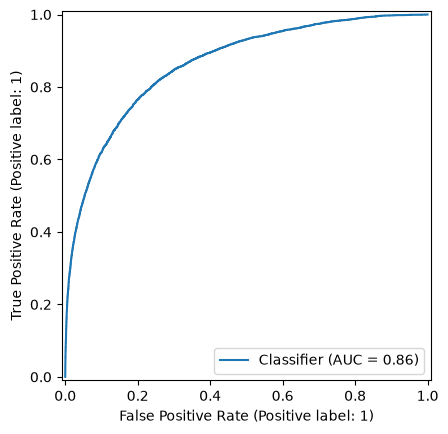

In [74]:
RocCurveDisplay.from_predictions(
    y_test,
    y_proba[:, 1]
)